# CUSTOMER SEGMENTATION ANALYSIS

## Project: Customer Segmentation Analysis

### Objective

The objective of this project is to analyze customer data and identify
different customer segments based on their characteristics and purchasing
behavior.

The analysis aims to understand customer patterns, identify distinct
customer groups, and generate meaningful business insights that can help
organizations improve customer targeting, marketing strategies, and
decision-making.

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("data.csv", encoding="latin1")

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [8]:
df.shape

(541909, 8)

In [9]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [10]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(5268)

In [13]:
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [15]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [16]:
missing_values = df.isnull().sum()

print(missing_values)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


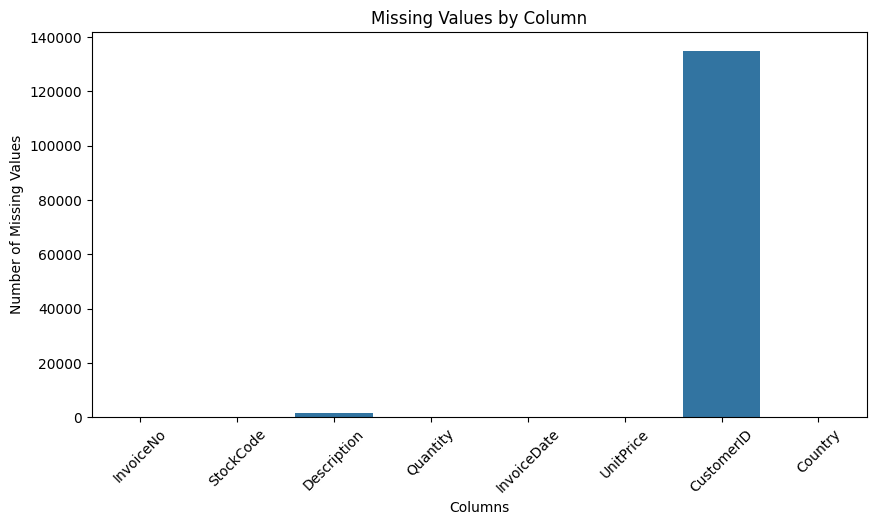

In [17]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.show()

In [18]:
df = df.dropna(subset=['CustomerID'])

print("Shape after removing missing CustomerID:")
print(df.shape)

Shape after removing missing CustomerID:
(406829, 8)


In [19]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 5225


In [20]:
df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)

Shape after removing duplicates:
(401604, 8)


In [21]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [22]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  int64         
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.6+ MB


In [24]:
cancelled_orders = df['InvoiceNo'].astype(str).str.startswith('C')

print("Cancelled orders:", cancelled_orders.sum())

Cancelled orders: 8872


In [25]:
df = df[~cancelled_orders]

print("Shape after removing cancelled orders:")
print(df.shape)

Shape after removing cancelled orders:
(392732, 8)


In [26]:
print(df[['Quantity', 'UnitPrice']].describe())

            Quantity      UnitPrice
count  392732.000000  392732.000000
mean       13.153718       3.125596
std       181.588420      22.240725
min         1.000000       0.000000
25%         2.000000       1.250000
50%         6.000000       1.950000
75%        12.000000       3.750000
max     80995.000000    8142.750000


In [27]:
df = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
]

print("Shape after removing invalid values:")
print(df.shape)


Shape after removing invalid values:
(392692, 8)


In [28]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [29]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [30]:
print("Total Customers:", df['CustomerID'].nunique())

print("Total Orders:", df['InvoiceNo'].nunique())

print("Total Revenue:", round(df['TotalAmount'].sum(), 2))

print("Average Transaction Value:",
      round(df['TotalAmount'].mean(), 2))

Total Customers: 4338
Total Orders: 18532
Total Revenue: 8887208.89
Average Transaction Value: 22.63


In [31]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [32]:
recency = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()

recency['Recency'] = (
    reference_date - recency['InvoiceDate']
).dt.days

recency = recency[['CustomerID', 'Recency']]

recency.head()

,CustomerID,Recency
0,12346,326
1,12347,2
2,12348,75
3,12349,19
4,12350,310


In [33]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

frequency.columns = ['CustomerID', 'Frequency']

frequency.head()

,CustomerID,Frequency
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1


In [34]:
monetary = df.groupby('CustomerID')['TotalAmount'].sum().reset_index()

monetary.columns = ['CustomerID', 'Monetary']

monetary.head()

,CustomerID,Monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


In [35]:
rfm = recency.merge(
    frequency,
    on='CustomerID'
)

rfm = rfm.merge(
    monetary,
    on='CustomerID'
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [36]:
rfm['AveragePurchaseValue'] = (
    rfm['Monetary'] / rfm['Frequency']
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,AveragePurchaseValue
0,12346,326,1,77183.60,77183.600000
1,12347,2,7,4310.00,615.714286
2,12348,75,4,1797.24,449.310000
3,12349,19,1,1757.55,1757.550000
4,12350,310,1,334.40,334.400000


In [37]:
rfm['CLV'] = rfm['Monetary']

### Customer Lifetime Value (CLV)

For this analysis, cumulative customer spending during the
observed transaction period is used as a simplified CLV proxy.
This provides an estimate of the customer's monetary value
within the available dataset.

In [38]:
rfm[
    [
        'Recency',
        'Frequency',
        'Monetary',
        'AveragePurchaseValue',
        'CLV'
    ]
].describe().round(2)

,Recency,Frequency,Monetary,AveragePurchaseValue,CLV
count,4338.00,4338.00,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69,417.65,2048.69
std,100.01,7.70,8985.23,1796.51,8985.23
min,1.00,1.00,3.75,3.45,3.75
25%,18.00,1.00,306.48,177.87,306.48
50%,51.00,2.00,668.57,291.94,668.57
75%,142.00,5.00,1660.60,428.28,1660.60
max,374.00,209.00,280206.02,84236.25,280206.02


In [39]:
features = rfm[['Recency', 'Frequency', 'Monetary']]

features.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [41]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(scaled_features)

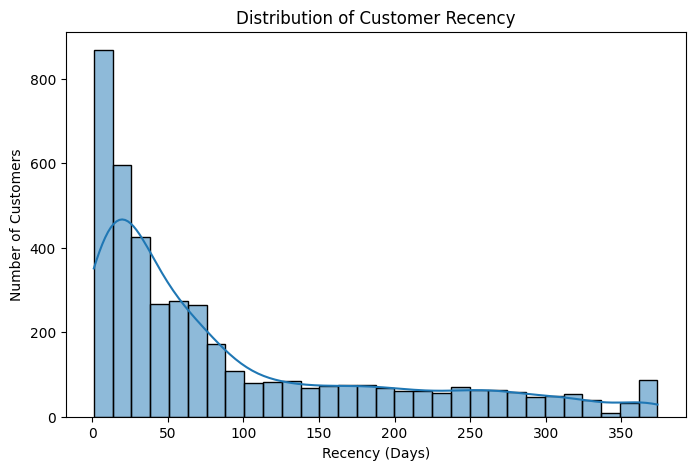

In [42]:
plt.figure(figsize=(8, 5))

sns.histplot(
    rfm['Recency'],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.show()

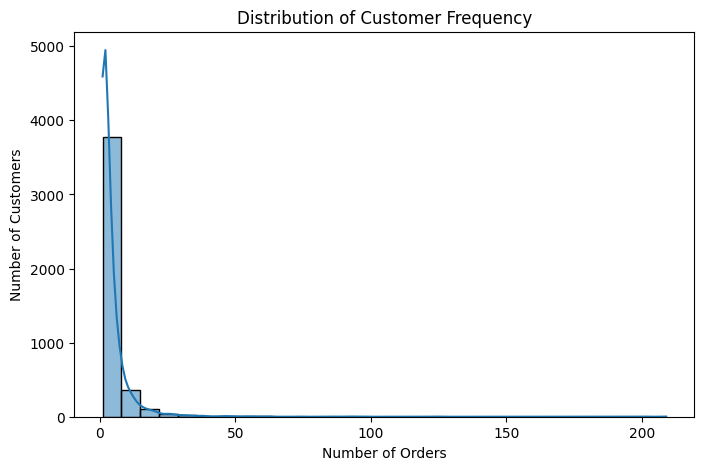

In [43]:
plt.figure(figsize=(8, 5))

sns.histplot(
    rfm['Frequency'],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

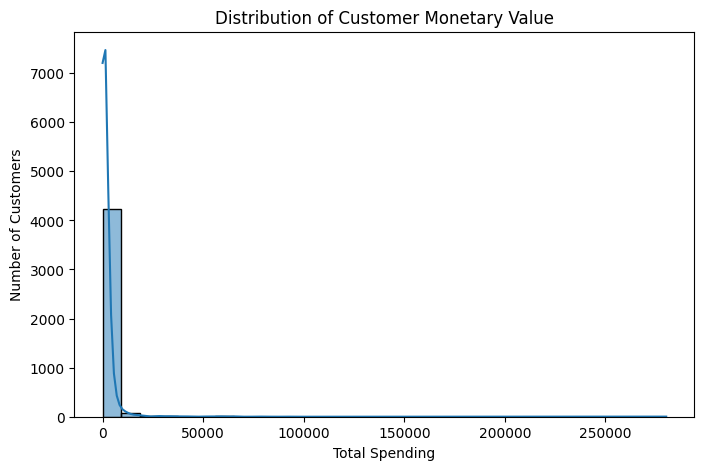

In [44]:
plt.figure(figsize=(8, 5))

sns.histplot(
    rfm['Monetary'],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Monetary Value")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

In [45]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(
    scaled_features,
    rfm['Cluster']
)

print("Silhouette Score:", round(silhouette_avg, 3))

Silhouette Score: 0.616


### Clustering Evaluation

The Silhouette Score was calculated to evaluate the quality of
the resulting customer clusters. A higher score indicates that
customers are generally better separated from customers in other
clusters.

In [46]:
features = rfm[
    ['Recency', 'Frequency', 'Monetary']
]

features.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


In [47]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features = pd.DataFrame(
    scaled_features,
    columns=[
        'Recency',
        'Frequency',
        'Monetary'
    ]
)

scaled_features.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


In [48]:
inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

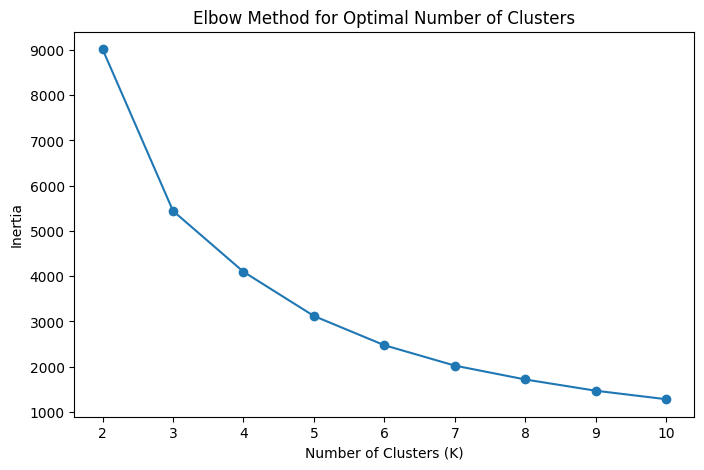

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker='o'
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(K_range)

plt.show()

In [50]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(scaled_features)

In [51]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,AveragePurchaseValue,CLV,Cluster
0,12346,326,1,77183.60,77183.600000,77183.60,3
1,12347,2,7,4310.00,615.714286,4310.00,0
2,12348,75,4,1797.24,449.310000,1797.24,0
3,12349,19,1,1757.55,1757.550000,1757.55,0
4,12350,310,1,334.40,334.400000,334.40,1


In [52]:
cluster_counts = (
    rfm['Cluster']
    .value_counts()
    .sort_index()
)

print(cluster_counts)

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


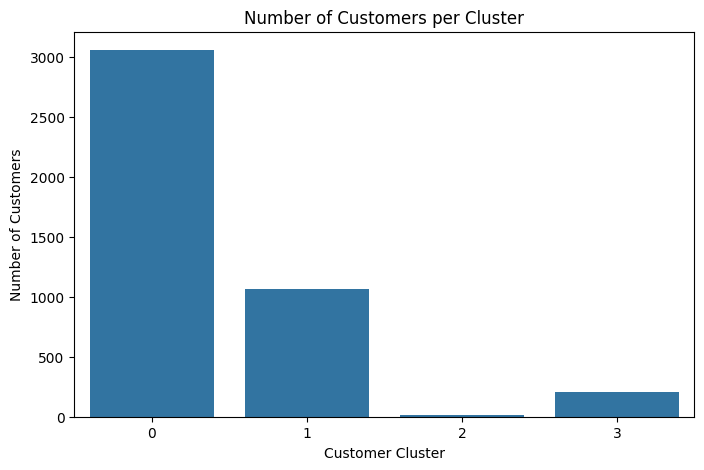

In [53]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x='Cluster'
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [54]:
cluster_profile = rfm.groupby('Cluster')[
    [
        'Recency',
        'Frequency',
        'Monetary',
        'AveragePurchaseValue',
        'CLV'
    ]
].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary,AveragePurchaseValue,CLV
Cluster,,,,,
0,43.70,3.68,1353.63,375.06,1353.63
1,248.08,1.55,478.85,313.70,478.85
2,7.38,82.54,127187.96,8569.26,127187.96
3,15.50,22.33,12690.50,1079.42,12690.50


In [55]:
cluster_profile['Customers'] = (
    rfm.groupby('Cluster')['CustomerID'].count()
)

cluster_profile

,Recency,Frequency,Monetary,AveragePurchaseValue,CLV,Customers
Cluster,,,,,,
0,43.70,3.68,1353.63,375.06,1353.63,3054
1,248.08,1.55,478.85,313.70,478.85,1067
2,7.38,82.54,127187.96,8569.26,127187.96,13
3,15.50,22.33,12690.50,1079.42,12690.50,204


In [56]:
cluster_profile = cluster_profile[
    [
        'Customers',
        'Recency',
        'Frequency',
        'Monetary',
        'AveragePurchaseValue',
        'CLV'
    ]
]

cluster_profile

,Customers,Recency,Frequency,Monetary,AveragePurchaseValue,CLV
Cluster,,,,,,
0,3054,43.70,3.68,1353.63,375.06,1353.63
1,1067,248.08,1.55,478.85,313.70,478.85
2,13,7.38,82.54,127187.96,8569.26,127187.96
3,204,15.50,22.33,12690.50,1079.42,12690.50


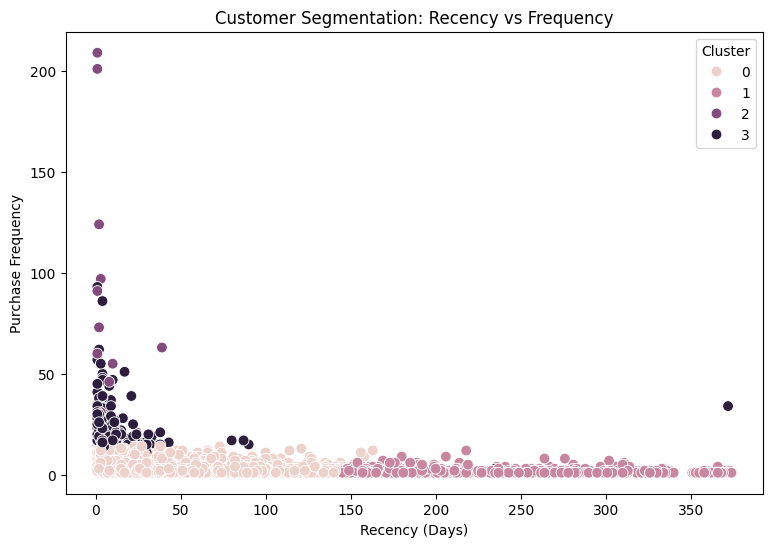

In [57]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    s=60
)

plt.title("Customer Segmentation: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Purchase Frequency")
plt.legend(title="Cluster")

plt.show()

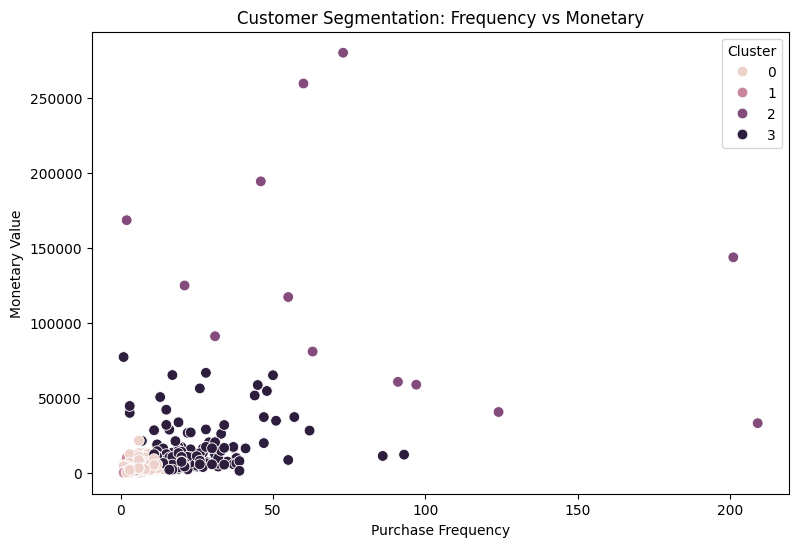

In [58]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    s=60
)

plt.title("Customer Segmentation: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")

plt.show()

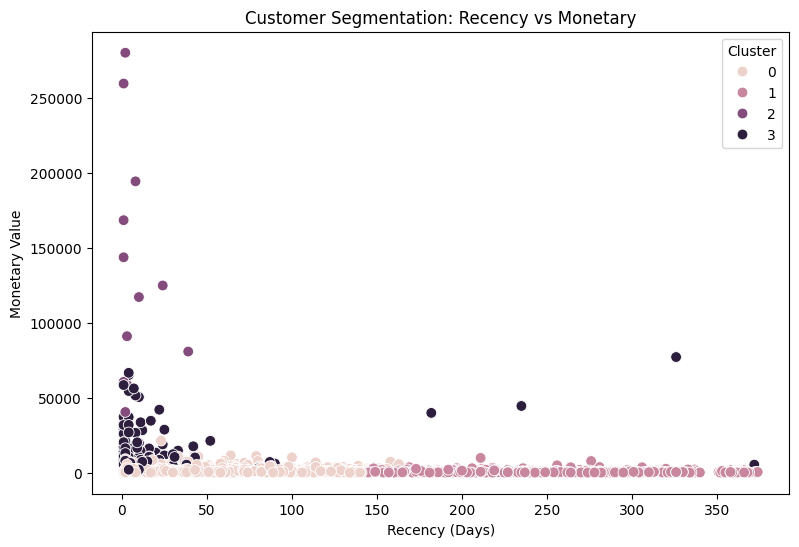

In [59]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    s=60
)

plt.title("Customer Segmentation: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")

plt.show()

In [60]:
final_summary = rfm.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_Purchase_Value=('AveragePurchaseValue', 'mean'),
    Avg_CLV=('CLV', 'mean')
).round(2)

final_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Purchase_Value,Avg_CLV
Cluster,,,,,,
0,3054,43.70,3.68,1353.63,375.06,1353.63
1,1067,248.08,1.55,478.85,313.70,478.85
2,13,7.38,82.54,127187.96,8569.26,127187.96
3,204,15.50,22.33,12690.50,1079.42,12690.50


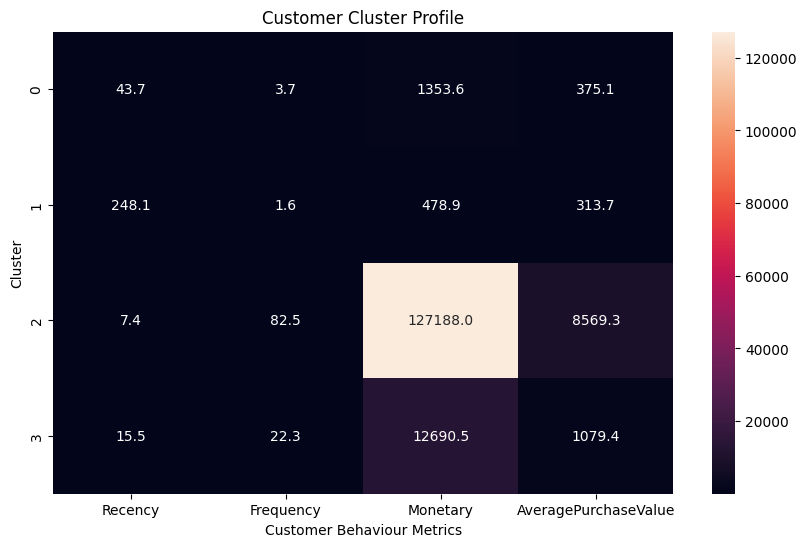

In [61]:
heatmap_data = cluster_profile[
    [
        'Recency',
        'Frequency',
        'Monetary',
        'AveragePurchaseValue'
    ]
]

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f'
)

plt.title("Customer Cluster Profile")
plt.xlabel("Customer Behaviour Metrics")
plt.ylabel("Cluster")

plt.show()

In [62]:
rfm.to_csv(
    "customer_segmentation_results.csv",
    index=False
)

print("Customer segmentation results saved!")

Customer segmentation results saved!


In [63]:
final_summary.to_csv(
    "cluster_summary.csv"
)

print("Cluster summary saved!")

Cluster summary saved!


In [64]:
silhouette_avg = silhouette_score(
    scaled_features,
    rfm['Cluster']
)

print(
    "Silhouette Score:",
    round(silhouette_avg, 3)
)

Silhouette Score: 0.616


# Marketing Recommendations

### Cluster 0 – Regular Customers
These customers form the largest customer group and show moderate
recency, frequency and monetary value.

**Recommendation:**
Use loyalty points, product bundles, cross-selling and personalized
offers to increase purchase frequency and customer value.

### Cluster 1 – Inactive / At-Risk Customers
These customers have relatively high recency and lower purchase
frequency and monetary value.

**Recommendation:**
Use re-engagement emails, personalized discounts and limited-time
offers to encourage customers to return.

### Cluster 2 – VIP Customers
These customers have very low recency, very high purchase frequency
and extremely high monetary value.

**Recommendation:**
Provide VIP rewards, exclusive offers, priority service, early access
to products and personalized recommendations.

### Cluster 3 – High-Value Loyal Customers
These customers purchase frequently, purchase recently and generate
high monetary value.

**Recommendation:**
Use loyalty programs, upselling, cross-selling and personalized
product recommendations to increase customer lifetime value.

# Conclusion

Customer segmentation was performed using K-Means clustering
based on Recency, Frequency and Monetary purchasing behaviour.

The analysis identified four customer groups with different
purchasing patterns. The largest group consists of regular
customers, while smaller groups represent inactive customers,
high-value loyal customers and a very high-value VIP segment.

These segments can help the business develop targeted marketing
strategies. VIP customers can receive exclusive rewards, regular
customers can be encouraged to purchase more frequently, and
inactive customers can be targeted with re-engagement campaigns.

Overall, RFM-based K-Means clustering provides a useful way to
understand customer behaviour and support data-driven marketing
decisions.